<p style="font-size: 20px;">
<b>Student Full Name:</b> Jasser Dhaouadi <br>
<b>Student ID:</b> U89818600 <br>
<b>Course:</b> Data Science Capstone - 1 <br>
<b>Semester:</b> Summer 2026 <br>
<b>Program:</b> OMDS <br>
<b>Boston University</b> 
</p>

# Week 2 - Linear Regression: Part 2 | Lasso, Ridge, and Elastic Net Regression

# Homework - Working On My Datasets

### Packages

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Preprocessing and splitting
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay, 
    precision_score,
    recall_score,
    average_precision_score,
    roc_auc_score
    
)

# Display settings
pd.set_option("display.max_columns", None)

### IMPORTANT NOTE:
- Because the target variable of our Diabetes Dataset contains three categories, this is a **multiclass classification problem, not a regression problem**.

- The three target classes are:
    - 0 = No diabetes
    - 1 = Prediabetes
    - 2 = Diabetes

- Since Week 2 covered **Lasso, Ridge, and Elastic Net regression**, we apply the same **regularization ideas using logistic regression penalties**:
    - Ridge-style classification      → Logistic Regression with L2 penalty
    - Lasso-style classification      → Logistic Regression with L1 penalty
    - Elastic Net classification      → Logistic Regression with elasticnet penalty

## Dataset 1: CDC Diabetes Health Indicators  (sourced from BRFSS) 

#### [Dataset 1] | *1- Load the dataset & quick preview*

In [2]:
# Load the dataset
df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")

# Display the first few rows
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


- The dataset contains **health, lifestyle, and demographic variables** from the CDC BRFSS 2015 survey.

- The target variable is **Diabetes_012**, which identifies whether the person has **no diabetes, prediabetes, or diabetes**.

- The goal is to use the available health indicators to predict diabetes status.

#### [Dataset 1] | *2- Inspect the dataset structure*

In [3]:
# Check dataset shape
print("Dataset shape:", df.shape)

# Check column names
print("\nColumn names:")
print(df.columns.tolist())

# Check basic information
df.info()

Dataset shape: (253680, 22)

Column names:
['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float

- From inspecting the uploaded CSV file, the dataset contains:
    - 253,680 rows
    - 22 columns

- The first column, Diabetes_012, is the target variable. The remaining 21 columns are predictor variables.

- The feature columns include variables such as:
    - HighBP
    - HighChol
    - BMI
    - Smoker
    - Stroke
    - HeartDiseaseorAttack
    - PhysActivity
    - Fruits
    - Veggies
    - GenHlth
    - MentHlth
    - PhysHlth
    - DiffWalk
    - Sex
    - Age
    - Education
    - Income

- Most variables are binary or ordinal health indicators.

- BMI, MentHlth, and PhysHlth are numeric variables.

#### [Dataset 1] | *3- Check missing values*

In [4]:
# Check missing values in each column
missing_values = df.isnull().sum()

missing_values

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

- If a dataset has missing values, we usually need to decide whether to remove rows, impute missing values, or handle missingness in another way.

- For this dataset, the uploaded CSV does not contain missing values, so we can continue without imputation.

#### [Dataset 1] | *4- Examine the target variable*

In [6]:
# Count the number of observations in each diabetes class
target_counts = df["Diabetes_012"].value_counts().sort_index()

print(target_counts)

# Convert counts to percentages
target_percentages = df["Diabetes_012"].value_counts(normalize=True).sort_index() * 100

print("\nClass percentages:")
print(target_percentages)

Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64

Class percentages:
Diabetes_012
0.0    84.241170
1.0     1.825528
2.0    13.933302
Name: proportion, dtype: float64


- The target variable Diabetes_012 has three classes:
    - 0 = No diabetes
    - 1 = Prediabetes
    - 2 = Diabetes

- From the uploaded dataset, the class counts are:
    - 0.0 → 213,703
    - 1.0 → 4,631
    - 2.0 → 35,346

- This shows that the dataset is highly **imbalanced**. The majority class is 0, meaning no diabetes. The prediabetes class, 1, is much smaller than the other two classes.

- This is important because a model could achieve high overall accuracy by mostly predicting the majority class. Therefore, we should not rely only on accuracy. We should also use metrics such as:
    - balanced accuracy
    - macro F1-score
    - class-specific precision
    - class-specific recall
    - class-specific F1-score


#### [Dataset 1] | *5- Visualize the target distribution*

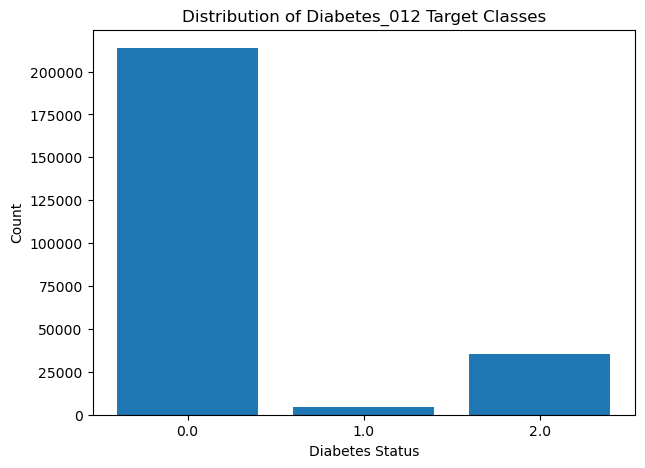

In [7]:
# Plot target class distribution
plt.figure(figsize=(7, 5))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.xlabel("Diabetes Status")
plt.ylabel("Count")
plt.title("Distribution of Diabetes_012 Target Classes")
plt.show()

- This bar chart visualizes the class imbalance in the target variable.

- The class 0, no diabetes, is much more frequent than the prediabetes and diabetes classes. This imbalance affects model training and evaluation.

- Because of this imbalance, we will use **class_weight="balanced"** in our logistic regression models. This gives more weight to minority classes during training.

#### [Dataset 1] | *6- Separate features and target + Train-test split*

In [8]:
# Separate target and features
X = df.drop(columns=["Diabetes_012"])
y = df["Diabetes_012"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Feature matrix shape: (253680, 21)
Target vector shape: (253680,)
Training feature shape: (202944, 21)
Testing feature shape: (50736, 21)

Training target distribution:
Diabetes_012
0.0    0.842410
1.0    0.018256
2.0    0.139334
Name: proportion, dtype: float64

Testing target distribution:
Diabetes_012
0.0    0.842420
1.0    0.018251
2.0    0.139329
Name: proportion, dtype: float64


- We use: **stratify=y**

- This preserves the same class distribution in both the training and testing sets. This is especially important because the dataset is imbalanced.

#### [Dataset 1] | *7- Create a helper function for model evaluation*

In [9]:
def evaluate_classifier(model, X_test, y_test, model_name):
    """
    Evaluates a classification model using multiple classification metrics.
    """
    # Generate predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    
    # Store results
    results = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_acc,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    }
    
    # Print results
    print(f"Results for {model_name}")
    print("-" * 50)
    print(f"Accuracy:          {accuracy:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"Macro F1:          {macro_f1:.4f}")
    print(f"Weighted F1:       {weighted_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return results

- We use:
    - Accuracy
    - Balanced Accuracy
    - Macro F1-score
    - Weighted F1-score
    - Classification report

- Accuracy alone can be **misleading** because the dataset is **imbalanced**.

- **Balanced Accuracy** is useful because it gives equal importance to each class.

- **Macro F1-score** is also useful because it calculates the F1-score for each class independently and then averages them equally. This prevents the majority class from dominating the evaluation.

#### [Dataset 1] | *8- Ridge-style logistic regression using L2 regularization*

In [10]:
# Ridge-style logistic regression using L2 penalty
ridge_logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegressionCV(
            Cs=[0.001, 0.01, 0.1, 1, 10, 100],
            cv=3,
            penalty="l2",
            solver="saga",
            scoring="f1_macro",
            class_weight="balanced",
            max_iter=2000,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Fit the Ridge-style logistic regression model
ridge_logistic_model.fit(X_train, y_train)

# Evaluate the model
ridge_results = evaluate_classifier(
    ridge_logistic_model,
    X_test,
    y_test,
    "Ridge Logistic Regression - L2"
)

C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter 

Results for Ridge Logistic Regression - L2
--------------------------------------------------
Accuracy:          0.6458
Balanced Accuracy: 0.5216
Macro F1:          0.4251
Weighted F1:       0.7208

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.67      0.78     42741
         1.0       0.03      0.33      0.06       926
         2.0       0.35      0.57      0.43      7069

    accuracy                           0.65     50736
   macro avg       0.44      0.52      0.43     50736
weighted avg       0.85      0.65      0.72     50736



- This model applies the Week 2 concept of **Ridge regularization to a classification problem**:
    - In **ordinary Ridge regression**, the model uses an L2 penalty, which penalizes the sum of squared coefficients.
    - In **classification**, we can apply the same idea using **logistic regression** with **penalty="l2"**
        - The **L2 penalty** shrinks coefficients toward zero but usually does not force them exactly to zero.
        - This means Ridge-style logistic regression keeps most or all features in the model while reducing the influence of less important predictors.

- This is useful when several features may contribute to diabetes prediction, but we want to control overfitting

- We use **LogisticRegressionCV** so that cross-validation can choose the best value of **C**.

- **Important note:**
    - C is the inverse of regularization strength.
    - Smaller C = stronger regularization.
    - Larger C = weaker regularization.

- So **C** plays the opposite role of **lambda (ordinary ridge regression)**.

#### [Dataset 1] | *9- Lasso-style logistic regression using L1 regularization*

In [11]:
# Lasso-style logistic regression using L1 penalty
lasso_logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegressionCV(
            Cs=[0.001, 0.01, 0.1, 1, 10, 100],
            cv=3,
            penalty="l1",
            solver="saga",
            scoring="f1_macro",
            class_weight="balanced",
            max_iter=3000,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Fit the Lasso-style logistic regression model
lasso_logistic_model.fit(X_train, y_train)

# Evaluate the model
lasso_results = evaluate_classifier(
    lasso_logistic_model,
    X_test,
    y_test,
    "Lasso Logistic Regression - L1"
)

C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter 

Results for Lasso Logistic Regression - L1
--------------------------------------------------
Accuracy:          0.5997
Balanced Accuracy: 0.4895
Macro F1:          0.3918
Weighted F1:       0.6879

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.63      0.76     42741
         1.0       0.03      0.37      0.06       926
         2.0       0.30      0.47      0.36      7069

    accuracy                           0.60     50736
   macro avg       0.43      0.49      0.39     50736
weighted avg       0.84      0.60      0.69     50736



C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


- This model applies the Week 2 concept of **Lasso regularization to the classification problem**:
    - In **ordinary Lasso regression**, the model uses an L1 penalty, which penalizes the sum of the absolute values of the coefficients.
    - In **logistic regression**, we apply the same idea using **penalty="l1"**
        - Lasso-style logistic regression can shrink some coefficients exactly to zero.
- This means Lasso can perform **feature selection** :
    - If a feature receives a coefficient of zero, the model is effectively ignoring that feature for prediction.
    - This is useful when we believe only some of the health indicators are strongly related to diabetes status.

- Because the dataset has many correlated health variables, Lasso may select one variable from a group of related predictors and shrink others to zero.

#### [Dataset 1] | *10- Elastic Net logistic regression*

In [12]:
# Elastic Net logistic regression using combined L1 and L2 penalty
elastic_net_logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegressionCV(
            Cs=[0.001, 0.01, 0.1, 1, 10, 100],
            cv=3,
            penalty="elasticnet",
            solver="saga",
            l1_ratios=[0.2, 0.5, 0.8],
            scoring="f1_macro",
            class_weight="balanced",
            max_iter=3000,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Fit the Elastic Net logistic regression model
elastic_net_logistic_model.fit(X_train, y_train)

# Evaluate the model
elastic_net_results = evaluate_classifier(
    elastic_net_logistic_model,
    X_test,
    y_test,
    "Elastic Net Logistic Regression"
)

C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter 

Results for Elastic Net Logistic Regression
--------------------------------------------------
Accuracy:          0.6500
Balanced Accuracy: 0.5203
Macro F1:          0.4271
Weighted F1:       0.7229

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.67      0.78     42741
         1.0       0.03      0.31      0.06       926
         2.0       0.35      0.59      0.44      7069

    accuracy                           0.65     50736
   macro avg       0.44      0.52      0.43     50736
weighted avg       0.85      0.65      0.72     50736



- This model applies the Week 2 concept of **Elastic Net regularization to classification**:
    - **Elastic Net** combines both **L1 and L2 penalties**.
    - In **logistic regression**, we use **penalty="elasticnet"**

- The **l1_ratio** controls the balance between Lasso and Ridge behavior:
    - l1_ratio = 0.0 → pure Ridge behavior
    - l1_ratio = 1.0 → pure Lasso behavior
    - l1_ratio between 0 and 1 → Elastic Net

- In this notebook, we test: l1_ratios=[0.2, 0.5, 0.8]
    - This allows cross-validation to choose whether the model should behave more like Ridge, more like Lasso, or somewhere in between.

- Elastic Net is especially useful when predictors are correlated because it can keep groups of related variables while still performing some feature selection.

#### [Dataset 1] | *11- Compare model performance*

In [13]:
# Combine all model results into a DataFrame
results_df = pd.DataFrame([
    ridge_results,
    lasso_results,
    elastic_net_results
])

# Sort by Macro F1 because this is useful for imbalanced multiclass classification
results_df = results_df.sort_values(by="Macro F1", ascending=False)

results_df

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
2,Elastic Net Logistic Regression,0.649972,0.520327,0.427107,0.722873
0,Ridge Logistic Regression - L2,0.645833,0.521561,0.425071,0.720770
1,Lasso Logistic Regression - L1,0.599673,0.489478,0.391768,0.687927


- Because this is an imbalanced multiclass classification problem, we should pay special attention to:
    - Balanced Accuracy
    - Macro F1

#### [Dataset 1] | *12- Plot model comparison*

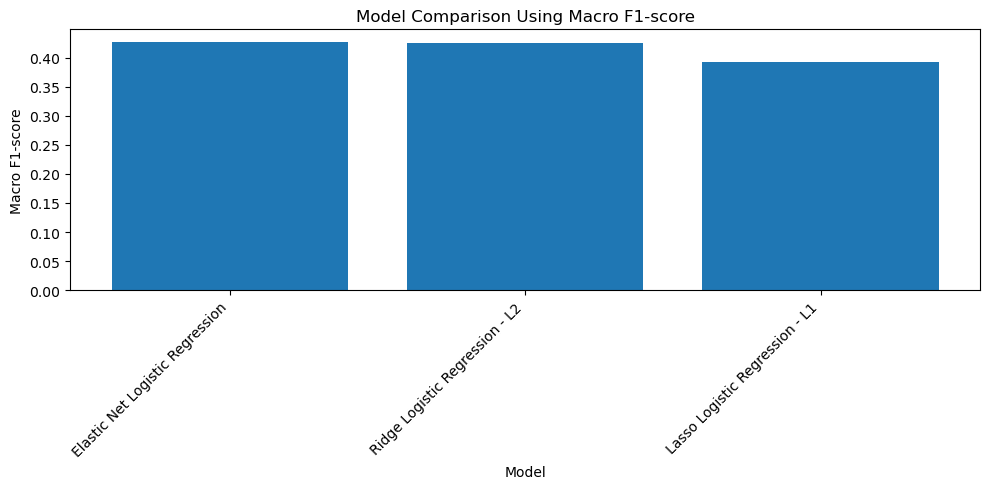

In [14]:
# Plot Macro F1 comparison
plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["Macro F1"])
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.title("Model Comparison Using Macro F1-score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### [Dataset 1] | *13- Display confusion matrix for the best model*

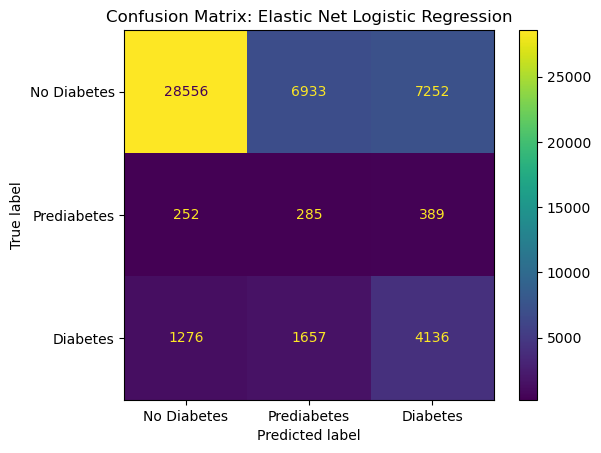

In [15]:
# Select the best model based on Macro F1-score
best_model_name = results_df.iloc[0]["Model"]

if best_model_name == "Ridge Logistic Regression - L2":
    best_model = ridge_logistic_model
elif best_model_name == "Lasso Logistic Regression - L1":
    best_model = lasso_logistic_model
elif best_model_name == "Elastic Net Logistic Regression":
    best_model = elastic_net_logistic_model
else:
    best_model = baseline_model

# Generate predictions
y_pred_best = best_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Prediabetes", "Diabetes"]
)

disp.plot(values_format="d")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

- The confusion matrix shows how the best model performs for each diabetes class.

- This helps us see where the model is making mistakes.

    - For example, we can observe whether the model often confuses:

        - Prediabetes with no diabetes
        - Diabetes with no diabetes
        - Prediabetes with diabetes

- This is important because in healthcare-related classification problems, the type of error matters.

- Missing people with diabetes or prediabetes may be more serious than incorrectly flagging someone as at risk.

#### [Dataset 1] | *14- Extract best hyperparameters*

In [16]:
# Function to extract best hyperparameters from a fitted pipeline
def extract_best_params(model_pipeline, model_name):
    model = model_pipeline.named_steps["model"]
    
    print(f"Best hyperparameters for {model_name}")
    print("-" * 60)
    
    # C values are stored per class in multinomial setting
    print("Best C values:")
    print(model.C_)
    
    # Elastic Net also has l1_ratio_
    if hasattr(model, "l1_ratio_"):
        print("\nBest l1_ratio values:")
        print(model.l1_ratio_)

# Extract selected hyperparameters
extract_best_params(ridge_logistic_model, "Ridge Logistic Regression - L2")
extract_best_params(lasso_logistic_model, "Lasso Logistic Regression - L1")
extract_best_params(elastic_net_logistic_model, "Elastic Net Logistic Regression")

Best hyperparameters for Ridge Logistic Regression - L2
------------------------------------------------------------
Best C values:
[0.01 0.01 0.01]

Best l1_ratio values:
[None None None]
Best hyperparameters for Lasso Logistic Regression - L1
------------------------------------------------------------
Best C values:
[0.001 0.001 0.001]

Best l1_ratio values:
[None None None]
Best hyperparameters for Elastic Net Logistic Regression
------------------------------------------------------------
Best C values:
[0.001 0.001 0.001]

Best l1_ratio values:
[0.8 0.8 0.8]


- This step displays the best regularization settings selected by cross-validation.

- For logistic regression in scikit-learn, the regularization strength is controlled by C.

    - The relationship is: C = inverse of lambda

    - So:

        - Small C  → stronger regularization
        - Large C  → weaker regularization

- For Elastic Net, we also inspect l1_ratio.

    - The selected l1_ratio tells us whether the model preferred more Ridge-like or more Lasso-like behavior:
        - l1_ratio = 1.0 (Pure Lasso)
        - l1_ratio = 0.0 (Pure Ridge)
        - l1_ratio = 0.5 (Perfect Balance)

#### [Dataset 1] | *15- Extract coefficients from the Ridge model*

In [17]:
# Extract feature names
feature_names = X.columns

# Extract coefficients from Ridge-style logistic regression
ridge_coefficients = ridge_logistic_model.named_steps["model"].coef_

# Convert to DataFrame
ridge_coef_df = pd.DataFrame(
    ridge_coefficients,
    columns=feature_names,
    index=["Class 0: No Diabetes", "Class 1: Prediabetes", "Class 2: Diabetes"]
)

ridge_coef_df

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
Class 0: No Diabetes,-0.178254,-0.198253,-0.137757,-0.316716,-0.003057,-0.001441,-0.023818,0.016006,0.015773,0.009209,0.076985,-0.003130,-0.041941,-0.342485,-0.011293,0.040634,-0.000022,-0.061685,-0.317782,0.038769,0.098990
Class 1: Prediabetes,0.000872,0.068037,0.021731,0.108390,-0.019270,-0.029450,-0.041284,0.006842,-0.006083,0.008236,0.033336,0.008593,0.050110,0.036405,0.050206,0.011844,-0.022619,-0.017594,0.158326,-0.036795,-0.067009
Class 2: Diabetes,0.177382,0.130216,0.116026,0.208326,0.022327,0.030890,0.065102,-0.022848,-0.009690,-0.017446,-0.110321,-0.005463,-0.008169,0.306080,-0.038913,-0.052478,0.022641,0.079279,0.159456,-0.001973,-0.031982


- Because this is a **multiclass classification** problem, the model learns a separate set of **coefficients for each class**.

- A **positive** coefficient means that higher values of that feature increase the model’s tendency to predict that class, relative to the other classes.

- A **negative** coefficient means that higher values of that feature decrease the model’s tendency to predict that class.

- Because Ridge uses L2 regularization, most coefficients are usually nonzero but shrunk toward smaller values.

#### [Dataset 1] | *16- Extract coefficients from the Lasso model*

In [18]:
# Extract coefficients from Lasso-style logistic regression
lasso_coefficients = lasso_logistic_model.named_steps["model"].coef_

# Convert to DataFrame
lasso_coef_df = pd.DataFrame(
    lasso_coefficients,
    columns=feature_names,
    index=["Class 0: No Diabetes", "Class 1: Prediabetes", "Class 2: Diabetes"]
)

lasso_coef_df

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
Class 0: No Diabetes,-0.153713,-0.234958,-0.157636,-0.379544,0.026242,0.017150,-0.028951,-0.012673,0.009943,0.005239,-0.002813,-0.037980,-0.022718,-0.320311,-0.039237,0.027612,0.027844,-0.049999,-0.404210,0.008784,0.092719
Class 1: Prediabetes,0.017550,0.101389,0.018762,-0.046590,0.120488,0.117301,-0.099805,-0.119417,-0.025194,0.131428,0.006652,0.380101,0.330341,-0.114073,-0.243601,0.004595,-0.003237,-0.054028,-0.001481,-0.107710,-0.045555
Class 2: Diabetes,0.196071,-0.063411,0.090566,0.120781,-0.153135,-0.130583,0.168908,0.104035,0.002602,-0.147775,-0.150790,-0.346656,-0.275918,0.317550,0.324827,-0.058817,-0.022805,0.111117,0.061074,0.039999,-0.036087


- Because Lasso uses L1 regularization, some coefficients may become exactly zero.

- A coefficient of zero means the model did not use that feature for predicting that specific class.

- This is how Lasso performs feature selection.

- In this diabetes classification problem, Lasso may help identify which health indicators are most useful for predicting diabetes status.

#### [Dataset 1] | *17- Identify features selected by Lasso*

In [19]:
# Count how many coefficients are zero for each feature across all classes
lasso_zero_counts = (lasso_coef_df == 0).sum(axis=0)

# Count how many coefficients are nonzero for each feature across all classes
lasso_nonzero_counts = (lasso_coef_df != 0).sum(axis=0)

# Create summary table
lasso_feature_selection = pd.DataFrame({
    "Feature": feature_names,
    "Nonzero Coefficients Across Classes": lasso_nonzero_counts.values,
    "Zero Coefficients Across Classes": lasso_zero_counts.values
})

# Sort by number of nonzero coefficients
lasso_feature_selection = lasso_feature_selection.sort_values(
    by="Nonzero Coefficients Across Classes",
    ascending=False
)

lasso_feature_selection

,Feature,Nonzero Coefficients Across Classes,Zero Coefficients Across Classes
0,HighBP,3,0
11,AnyHealthcare,3,0
19,Education,3,0
18,Age,3,0
17,Sex,3,0
16,DiffWalk,3,0
15,PhysHlth,3,0
14,MentHlth,3,0
13,GenHlth,3,0
12,NoDocbcCost,3,0


- This step summarizes the **feature selection behavior of Lasso**.

- For each feature, we count **how many class-specific coefficients are nonzero**.

- Since there are three classes, each feature can have up to three coefficients:

    - One coefficient for class 0
    - One coefficient for class 1
    - One coefficient for class 2

- If a feature has many zero coefficients, Lasso is reducing the importance of that feature.

- If a feature has nonzero coefficients across multiple classes, Lasso considers that feature useful for distinguishing diabetes status.

- This connects directly to the Week 2 idea that Lasso can shrink some coefficients to zero and therefore remove less useful predictors

#### [Dataset 1] | *18- Extract coefficients from the Elastic Net model*

In [20]:
# Extract coefficients from Elastic Net logistic regression
elastic_net_coefficients = elastic_net_logistic_model.named_steps["model"].coef_

# Convert to DataFrame
elastic_net_coef_df = pd.DataFrame(
    elastic_net_coefficients,
    columns=feature_names,
    index=["Class 0: No Diabetes", "Class 1: Prediabetes", "Class 2: Diabetes"]
)

elastic_net_coef_df

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
Class 0: No Diabetes,-0.175118,-0.276646,-0.122813,-0.390965,0.0,0.000000,0.00000,0.000698,0.008426,0.002243,0.020150,0.000000,-0.004478,-0.353094,0.000000,0.003269,0.000000,-0.029315,-0.414256,0.033983,0.132807
Class 1: Prediabetes,0.000000,0.000000,0.000000,0.000000,0.0,-0.010670,0.00000,0.000000,0.000000,0.000000,0.000000,-0.008342,0.065352,0.000000,0.040697,0.000000,-0.005306,0.000000,0.000000,-0.024476,-0.004497
Class 2: Diabetes,0.186892,0.006042,0.052202,0.111216,0.0,0.030925,0.07082,-0.013671,-0.001493,0.000000,-0.116095,0.002139,0.000000,0.241263,-0.012909,0.000000,0.023402,0.070883,0.051588,0.000000,0.000000


- Elastic Net combines both Ridge and Lasso behavior.

- This means it can:

    - Shrink coefficients like Ridge
    - Set some coefficients to zero like Lasso
    - Handle correlated predictors better than pure Lasso

- In this dataset, many health indicators may be related to each other. For example, general health, physical health, difficulty walking, high blood pressure, and BMI may all be connected.

- Elastic Net is useful because it can keep groups of related predictors while still reducing the influence of less useful variables.

#### [Dataset 1] | *19- Compare coefficient magnitudes across models*

In [21]:
# Calculate mean absolute coefficient for each feature in each model
ridge_importance = np.abs(ridge_coef_df).mean(axis=0)
lasso_importance = np.abs(lasso_coef_df).mean(axis=0)
elastic_net_importance = np.abs(elastic_net_coef_df).mean(axis=0)

# Combine into one DataFrame
coefficient_comparison = pd.DataFrame({
    "Feature": feature_names,
    "Ridge Mean Abs Coefficient": ridge_importance.values,
    "Lasso Mean Abs Coefficient": lasso_importance.values,
    "Elastic Net Mean Abs Coefficient": elastic_net_importance.values
})

# Sort by Elastic Net importance
coefficient_comparison = coefficient_comparison.sort_values(
    by="Elastic Net Mean Abs Coefficient",
    ascending=False
)

coefficient_comparison

,Feature,Ridge Mean Abs Coefficient,Lasso Mean Abs Coefficient,Elastic Net Mean Abs Coefficient
13,GenHlth,0.228324,0.250645,0.198119
3,BMI,0.211144,0.182305,0.167394
18,Age,0.211855,0.155588,0.155281
0,HighBP,0.118836,0.122445,0.120670
1,HighChol,0.132168,0.133253,0.094229
2,CholCheck,0.091838,0.088988,0.058338
20,Income,0.065994,0.058120,0.045768
10,HvyAlcoholConsump,0.073548,0.053418,0.045415
17,Sex,0.052853,0.071715,0.033399
6,HeartDiseaseorAttack,0.043401,0.099221,0.023607


- This step compares the **average absolute coefficient size** for each feature across the three regularized logistic regression models.

- The absolute coefficient size gives a rough measure of feature importance.

- However, coefficient interpretation should be done carefully because:

    - Features are scaled before modeling.
    - Coefficients are class-specific.
    - Some variables are binary while others are ordinal or continuous.
    - Correlation among predictors can affect coefficient values.

- Still, this table helps us compare how Ridge, Lasso, and Elastic Net treat the features differently.

    - Ridge usually keeps more features with smaller coefficients.

    - Lasso may set some coefficients to zero.

    - Elastic Net usually gives a balance between the two.

#### [Dataset 1] | *20- Plot top Elastic Net coefficients for diabetes class*

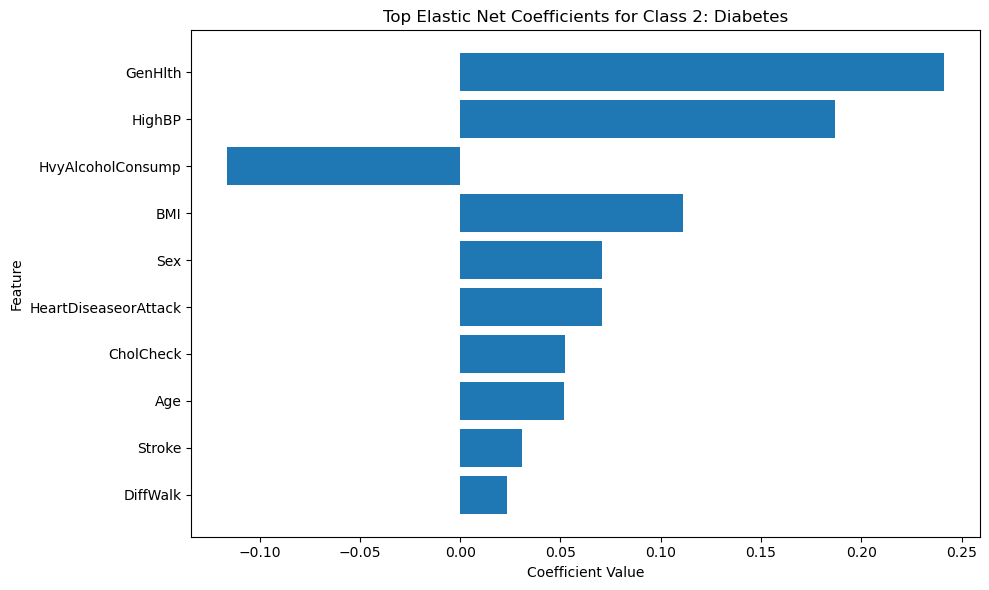

In [22]:
# Focus on Class 2: Diabetes
diabetes_class_coefficients = elastic_net_coef_df.loc["Class 2: Diabetes"]

# Get top 10 features by absolute coefficient size
top_diabetes_features = diabetes_class_coefficients.abs().sort_values(ascending=False).head(10)

# Keep original signs
top_diabetes_coefficients = diabetes_class_coefficients[top_diabetes_features.index]

# Plot top coefficients
plt.figure(figsize=(10, 6))
plt.barh(top_diabetes_coefficients.index, top_diabetes_coefficients.values)
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top Elastic Net Coefficients for Class 2: Diabetes")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

- This step focuses specifically on the class: **2 = Diabetes**

- The chart shows the **top features** that the Elastic Net model uses when predicting diabetes.

- **Positive coefficients** increase the model’s tendency to predict diabetes.

- **Negative coefficients** decrease the model’s tendency to predict diabetes.

- This is useful because it connects the predictive model back to real health indicators:

    - For example, variables such as high blood pressure, BMI, general health, age, and difficulty walking may be important predictors depending on the fitted coefficients.

#### [Dataset 1] | *21- Final classification report for the best model*

In [23]:
# Print final classification report for the best model
print(f"Final Classification Report for Best Model: {best_model_name}")
print("-" * 70)
print(classification_report(y_test, y_pred_best, target_names=[
    "No Diabetes",
    "Prediabetes",
    "Diabetes"
]))

Final Classification Report for Best Model: Elastic Net Logistic Regression
----------------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.95      0.67      0.78     42741
 Prediabetes       0.03      0.31      0.06       926
    Diabetes       0.35      0.59      0.44      7069

    accuracy                           0.65     50736
   macro avg       0.44      0.52      0.43     50736
weighted avg       0.85      0.65      0.72     50736



#### [Dataset 1] | *22- Conclusion*



This analysis applied Ridge-, Lasso-, and Elastic Net-regularized multinomial logistic regression to predict the three diabetes-status classes: no diabetes, prediabetes, and diabetes. Because the predictors were standardized before model fitting, the coefficient magnitudes can be compared across variables; however, they should be interpreted as changes in class-specific log-odds rather than as causal effects.

Across the three regularization approaches, general health status (`GenHlth`), body mass index (`BMI`), age, high blood pressure (`HighBP`), and high cholesterol (`HighChol`) consistently had some of the largest average absolute coefficients. This indicates that these variables provided the strongest linear separation among the diabetes classes. For the diabetes class specifically, the Elastic Net model assigned the largest positive coefficients to `GenHlth`, `HighBP`, `BMI`, `Sex`, `HeartDiseaseorAttack`, `CholCheck`, and `Age`. Holding the remaining predictors constant, larger values of these variables increased the model's relative tendency to classify an observation as diabetic.

The coefficient signs were generally clinically plausible. Poorer general health, higher BMI, high blood pressure, older age, and a history of cardiovascular disease were associated with a greater relative probability of diabetes. Conversely, the negative Elastic Net coefficient for `HvyAlcoholConsump` should not be interpreted as evidence that heavy alcohol consumption protects against diabetes. This association may reflect survey coding, confounding, selection effects, or relationships with other predictors included in the model. The coefficients describe conditional predictive associations and do not establish causality.

The three penalties produced noticeably different coefficient structures. Ridge retained all predictors and distributed their effects across correlated variables, consistent with the behavior of an L2 penalty. Lasso produced larger changes in several class-specific coefficients and emphasized variables such as `AnyHealthcare`, `NoDocbcCost`, and `MentHlth`, illustrating that L1 regularization can select among correlated predictors and may produce less stable coefficient allocations. Elastic Net created the sparsest and most interpretable solution: several coefficients were reduced exactly to zero, including the coefficients for `Smoker` across all three classes and multiple coefficients for the prediabetes class. At the same time, it retained groups of related predictors through its L2 component. This supports the use of Elastic Net when both feature selection and multicollinearity management are desired.

Elastic Net was selected as the best model according to the chosen validation criterion, but its test performance shows important limitations. The model achieved an accuracy of 0.65, a balanced accuracy of approximately 0.52, a macro F1-score of 0.43, and a weighted F1-score of 0.72. The large difference between weighted and macro F1 reflects the strong class imbalance in the dataset.

Performance varied substantially by class:

- No diabetes: precision = 0.95, recall = 0.67, and F1 = 0.78.
- Prediabetes: precision = 0.03, recall = 0.31, and F1 = 0.06.
- Diabetes: precision = 0.35, recall = 0.59, and F1 = 0.44.

The model therefore identified the no-diabetes class reasonably well and detected a moderate proportion of diabetes cases, but it performed poorly for prediabetes. Although class weighting increased sensitivity to the minority classes, it also generated many false-positive predictions, particularly for prediabetes. The extremely low prediabetes precision suggests that the available predictors do not provide sufficient linear separation for this small and potentially overlapping class.

Overall, Elastic Net provided the best compromise between predictive performance, coefficient shrinkage, and model interpretability. Nevertheless, the modest macro F1-score and weak prediabetes performance indicate that regularized linear decision boundaries alone are insufficient for accurately distinguishing all three diabetes-status groups. Further work should investigate alternative class-weight configurations, threshold adjustment, resampling methods, repeated stratified cross-validation, interaction terms, nonlinear transformations, and nonlinear classifiers. Any improvement should be assessed using macro F1-score, balanced accuracy, class-specific recall, and confusion matrices rather than overall accuracy alone.

## Dataset 2 & 3

### IMPORTANT NOTE:
- This notebook applies **regularized logistic regression** to Dataset 2 (**Obesity levels**) and Dataset 3 (**Cervical Cancer**).

- The Week 2 concepts are **Lasso, Ridge, and Elastic Net regularization**. 

- Since **both datasets are classification problems**, the classification version is **logistic regression with different penalties**:

    - Lasso-style logistic regression uses an L1 penalty.
    - Ridge-style logistic regression uses an L2 penalty.
    - Elastic-net logistic regression combines L1 and L2 penalties.

- The preprocessed datasets are loaded directly, so this notebook focuses on model training, tuning, evaluation, and coefficient interpretation.

#### [Dataset 2 & 3] | *Define helper functions*

In [4]:
def tune_regularized_models(X_train, y_train, scoring_metric):
    cv_strategy = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )
    
    c_values = [0.01, 0.1, 1, 10]
    
    model_specs = {
        "Lasso-style logistic regression": (
            LogisticRegression(
                penalty="l1",
                solver="saga",
                max_iter=1200,
                tol=0.05,
                class_weight="balanced",
                random_state=42
            ),
            {"logit__C": c_values}
        ),
        "Ridge-style logistic regression": (
            LogisticRegression(
                penalty="l2",
                solver="saga",
                max_iter=1200,
                tol=0.05,
                class_weight="balanced",
                random_state=42
            ),
            {"logit__C": c_values}
        ),
        "Elastic-net logistic regression": (
            LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                max_iter=1200,
                tol=0.05,
                class_weight="balanced",
                random_state=42
            ),
            {
                "logit__C": c_values,
                "logit__l1_ratio": [0.25, 0.50, 0.75]
            }
        )
    }
    
    fitted_searches = {}
    
    for model_name, (estimator, parameter_grid) in model_specs.items():
        pipe = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("logit", estimator)
            ]
        )
        
        search = GridSearchCV(
            estimator=pipe,
            param_grid=parameter_grid,
            scoring=scoring_metric,
            cv=cv_strategy,
            n_jobs=1,
            refit=True
        )
        
        search.fit(X_train, y_train)
        fitted_searches[model_name] = search
    
    return fitted_searches


def summarize_active_features(fitted_searches, feature_names):
    rows = []
    
    for model_name, search in fitted_searches.items():
        fitted_model = search.best_estimator_.named_steps["logit"]
        coefficients = fitted_model.coef_
        
        active_mask = np.any(np.abs(coefficients) > 1e-8, axis=0)
        best_params = search.best_params_
        
        rows.append({
            "Model": model_name,
            "Best C": best_params.get("logit__C"),
            "Best l1_ratio": best_params.get("logit__l1_ratio", np.nan),
            "Active Features": int(active_mask.sum()),
            "Zeroed Features": int(len(feature_names) - active_mask.sum()),
            "Total Features": len(feature_names),
            "Best CV Score": search.best_score_
        })
    
    return pd.DataFrame(rows)


def get_top_coefficients(search, feature_names, class_label=None, top_n=15):
    fitted_model = search.best_estimator_.named_steps["logit"]
    classes = fitted_model.classes_
    coefficients = fitted_model.coef_
    
    if len(classes) == 2:
        coefficient_vector = coefficients[0]
        selected_label = f"{classes[1]}"
    else:
        if class_label is None:
            class_label = classes[-1]
        class_index = list(classes).index(class_label)
        coefficient_vector = coefficients[class_index]
        selected_label = class_label
    
    coefficient_table = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficient_vector,
        "Absolute Coefficient": np.abs(coefficient_vector)
    })
    
    coefficient_table = coefficient_table.sort_values(
        "Absolute Coefficient",
        ascending=False
    )
    
    return selected_label, coefficient_table.head(top_n)


def evaluate_multiclass_models(fitted_searches, X_test, y_test):
    rows = []
    
    for model_name, search in fitted_searches.items():
        fitted_model = search.best_estimator_
        y_pred = fitted_model.predict(X_test)
        y_prob = fitted_model.predict_proba(X_test)
        classes = fitted_model.named_steps["logit"].classes_
        
        rows.append({
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
            "Macro F1": f1_score(y_test, y_pred, average="macro"),
            "Weighted F1": f1_score(y_test, y_pred, average="weighted"),
            "Macro OVR ROC AUC": roc_auc_score(
                y_test,
                y_prob,
                multi_class="ovr",
                average="macro",
                labels=classes
            )
        })
    
    return pd.DataFrame(rows).set_index("Model")


def evaluate_binary_models(fitted_searches, X_test, y_test):
    rows = []
    
    for model_name, search in fitted_searches.items():
        fitted_model = search.best_estimator_
        y_pred = fitted_model.predict(X_test)
        y_prob = fitted_model.predict_proba(X_test)[:, 1]
        
        rows.append({
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1": f1_score(y_test, y_pred, zero_division=0),
            "ROC AUC": roc_auc_score(y_test, y_prob),
            "Average Precision": average_precision_score(y_test, y_prob)
        })
    
    return pd.DataFrame(rows).set_index("Model")


def plot_metric_comparison(metric_table, title):
    metric_table.plot(
        kind="bar",
        figsize=(10, 6)
    )
    
    plt.title(title)
    plt.ylabel("Score")
    plt.xticks(rotation=20, ha="right")
    plt.ylim(0, 1)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


def plot_active_features(active_table, title):
    plot_data = active_table.set_index("Model")[["Active Features", "Zeroed Features"]]
    
    plot_data.plot(
        kind="bar",
        figsize=(10, 6)
    )
    
    plt.title(title)
    plt.ylabel("Number of Features")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

## Dataset 2: Obesity Levels

#### [Dataset 2] | *1- Load preprocessed obesity dataset*

In [11]:
obesity_path = "obesity_preprocessed_wk1.csv"

df_obesity_model = pd.read_csv(obesity_path)

print("Obesity dataset shape:", df_obesity_model.shape)
display(df_obesity_model.head())

Obesity dataset shape: (2111, 24)


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_with_overweight_yes,FAVC_yes,CAEC_Frequently,CAEC_Sometimes,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,NObeyesdad
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,Normal_Weight
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0,0,1,0,0,1,0,1,1,0,1,0,0,0,1,0,Normal_Weight
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0,1,1,0,0,1,0,0,0,1,0,0,0,0,1,0,Normal_Weight
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,Overweight_Level_I
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,Overweight_Level_II


#### [Dataset 2] | *2- Split obesity predictors and target*

In [12]:
obesity_target = "NObeyesdad"

X_obesity = df_obesity_model.drop(columns=[obesity_target])
y_obesity = df_obesity_model[obesity_target]

X_obesity_train, X_obesity_test, y_obesity_train, y_obesity_test = train_test_split(
    X_obesity,
    y_obesity,
    test_size=0.20,
    random_state=42,
    stratify=y_obesity
)

print("Training shape:", X_obesity_train.shape)
print("Testing shape:", X_obesity_test.shape)

display(y_obesity.value_counts().to_frame("Class Count"))

Training shape: (1688, 23)
Testing shape: (423, 23)


,Class Count
NObeyesdad,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


- The target variable is `NObeyesdad`, which represents obesity level. This is a multiclass classification problem.

- A stratified train-test split is used so that each obesity class keeps approximately the same proportion in both the training and testing sets. 

- This is important because the model should learn all obesity categories, not only the largest ones.

#### [Dataset 2] | *3- Tune Lasso-style, Ridge-style, and Elastic-net models*

In [13]:
obesity_searches = tune_regularized_models(
    X_train=X_obesity_train,
    y_train=y_obesity_train,
    scoring_metric="f1_macro"
)

obesity_tuning_summary = summarize_active_features(
    obesity_searches,
    X_obesity.columns
)

display(obesity_tuning_summary)

d:\BU\Summer 2026\DX799 O1 Data Science Capstone\HWs\MOD-C-1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\BU\Summer 2026\DX799 O1 Data Science Capstone\HWs\MOD-C-1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
d:\BU\Summer 2026\DX799 O1 Data Science Capstone\HWs\MOD-C-1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, l

,Model,Best C,Best l1_ratio,Active Features,Zeroed Features,Total Features,Best CV Score
0,Lasso-style logistic regression,10,NaN,23,0,23,0.728971
1,Ridge-style logistic regression,10,NaN,23,0,23,0.728288
2,Elastic-net logistic regression,10,0.25,23,0,23,0.728971


- This cell tunes **3 regularized logistic regression models**

- **Macro F1** is used because this is a **multiclass classification problem**. 

    - It gives each class equal importance instead of allowing the largest class to dominate the score.

- The active-feature counts show the main Week 2 idea:
    - Lasso-style regularization is expected to set more coefficients to zero. 
    - Ridge-style regularization usually keeps most coefficients active. 
    - Elastic net balances both behaviors.


The executed tuning summary was:

| Model | Best C | Best l1_ratio | Active Features | Zeroed Features | Total Features | Best CV Score |
|---|---:|---:|---:|---:|---:|---:|
| Lasso-style logistic regression | 10 | NaN | 23 | 0 | 23 | 0.728971 |
| Ridge-style logistic regression | 10 | NaN | 23 | 0 | 23 | 0.728288 |
| Elastic-net logistic regression | 10 | 0.25 | 23 | 0 | 23 | 0.728971 |


- For this obesity dataset, none of the models removed features. 
    - The best **`C` was 10**, which means the selected models preferred weaker regularization. 
    - This suggests that most predictors were useful enough that even the **Lasso-style model did not shrink them to zero**.

#### [Dataset 2] | *4- Evaluate obesity models*

In [14]:
obesity_metrics = evaluate_multiclass_models(
    obesity_searches,
    X_obesity_test,
    y_obesity_test
)

display(obesity_metrics)

,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC
Model,,,,,
Lasso-style logistic regression,0.763593,0.761782,0.751715,0.753715,0.947528
Ridge-style logistic regression,0.763593,0.761782,0.751715,0.753715,0.947355
Elastic-net logistic regression,0.763593,0.761782,0.751715,0.753715,0.947375


The three obesity models produced almost identical test performance.

The executed results were:

| Model | Accuracy | Balanced Accuracy | Macro F1 | Weighted F1 | Macro OVR ROC AUC |
|---|---:|---:|---:|---:|---:|
| Lasso-style logistic regression | 0.763593 | 0.761782 | 0.751715 | 0.753715 | 0.947528 |
| Ridge-style logistic regression | 0.763593 | 0.761782 | 0.751715 | 0.753715 | 0.947355 |
| Elastic-net logistic regression | 0.763593 | 0.761782 | 0.751715 | 0.753715 | 0.947375 |

- All three models reached about 76.4% accuracy and about 75.2% macro F1. The ROC AUC values are high, around 0.947, meaning the models rank the obesity classes well even though some class-label predictions are still confused.

- Since **Lasso-style** and **Elastic-net** models did not remove features, their main benefit here is **coefficient shrinkage** rather than **feature selection**.

#### [Dataset 2] | *5- Visualize obesity model performance and feature activity*

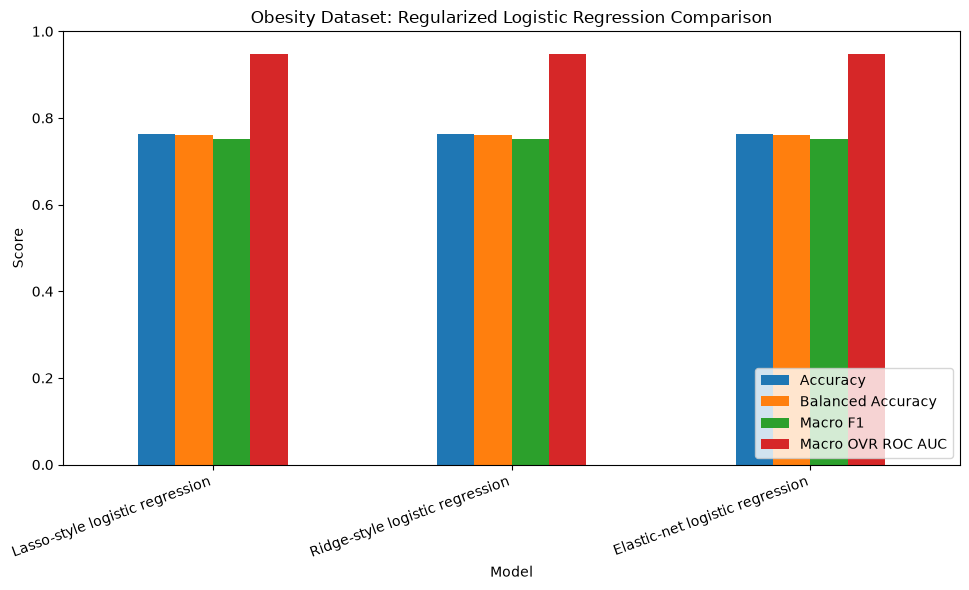

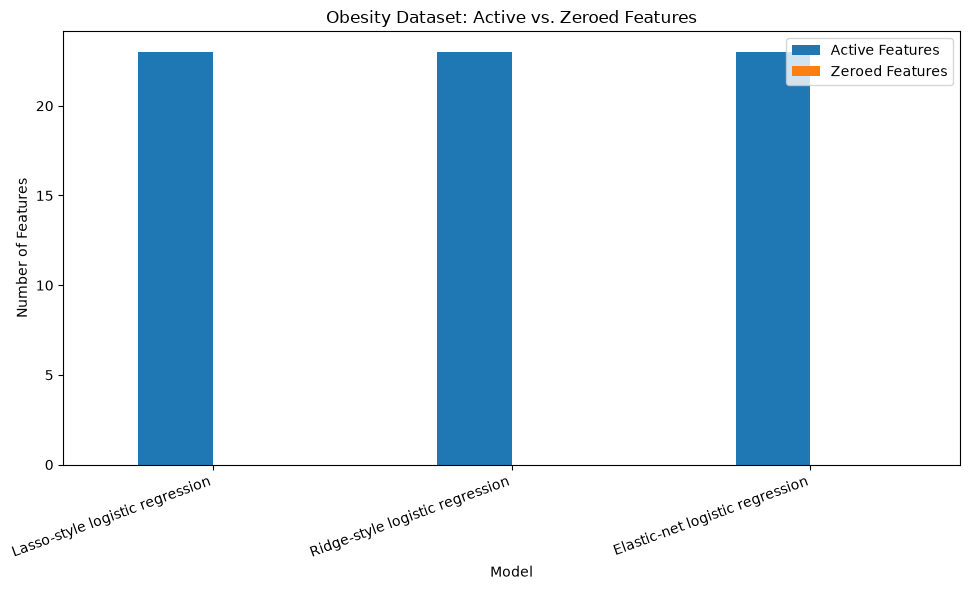

In [15]:
plot_metric_comparison(
    obesity_metrics[["Accuracy", "Balanced Accuracy", "Macro F1", "Macro OVR ROC AUC"]],
    "Obesity Dataset: Regularized Logistic Regression Comparison"
)

plot_active_features(
    obesity_tuning_summary,
    "Obesity Dataset: Active vs. Zeroed Features"
)

- The first plot shows that **all three regularized models performed nearly the same** on the obesity dataset.

- The second plot shows that **all 23 features stayed active for every model**. 

    - This is important because **Lasso-style regularization does not always remove features**. 
    - In this execution, the **best `C` value was 10**, so the **regularization was not strong enough to force any coefficients to zero**.

- This result suggests that the **predictors** in the preprocessed obesity dataset **all contributed some useful information** to the classification task.

#### [Dataset 2] | *6- Select best obesity model and inspect coefficients*

In [16]:
best_obesity_name = obesity_metrics["Macro F1"].idxmax()
best_obesity_search = obesity_searches[best_obesity_name]

print("Best obesity model based on test Macro F1:", best_obesity_name)
print("Best parameters:", best_obesity_search.best_params_)

selected_obesity_class = "Obesity_Type_III"

if selected_obesity_class not in best_obesity_search.best_estimator_.named_steps["logit"].classes_:
    selected_obesity_class = best_obesity_search.best_estimator_.named_steps["logit"].classes_[-1]

obesity_class_label, obesity_top_coefficients = get_top_coefficients(
    search=best_obesity_search,
    feature_names=X_obesity.columns,
    class_label=selected_obesity_class,
    top_n=15
)

print("Coefficient class:", obesity_class_label)
display(obesity_top_coefficients)

Best obesity model based on test Macro F1: Lasso-style logistic regression
Best parameters: {'logit__C': 10}
Coefficient class: Obesity_Type_III


,Feature,Coefficient,Absolute Coefficient
2,Weight,2.168791,2.168791
8,Gender_Male,-1.476667,1.476667
3,FCVC,1.165355,1.165355
21,MTRANS_Public_Transportation,0.566740,0.566740
4,NCP,0.515162,0.515162
6,FAF,-0.451755,0.451755
1,Height,-0.423995,0.423995
17,CALC_Sometimes,0.410644,0.410644
18,CALC_no,-0.374701,0.374701
10,FAVC_yes,0.318855,0.318855


- The best obesity model based on test macro F1 was:

| Best Model | Best Parameters |
|---|---|
| Lasso-style logistic regression | `C = 10` |


- The selected class for coefficient interpretation was `Obesity_Type_III`.


- The strongest coefficients for `Obesity_Type_III` were:

| Feature | Coefficient | Absolute Coefficient |
|---|---:|---:|
| Weight | 2.168791 | 2.168791 |
| Gender_Male | -1.476667 | 1.476667 |
| FCVC | 1.165355 | 1.165355 |
| MTRANS_Public_Transportation | 0.566740 | 0.566740 |
| NCP | 0.515162 | 0.515162 |
| FAF | -0.451755 | 0.451755 |
| Height | -0.423995 | 0.423995 |
| CALC_Sometimes | 0.410644 | 0.410644 |
| CALC_no | -0.374701 | 0.374701 |
| FAVC_yes | 0.318855 | 0.318855 |
| CH2O | 0.259936 | 0.259936 |
| CALC_Frequently | -0.120363 | 0.120363 |
| TUE | -0.102012 | 0.102012 |
| CAEC_Frequently | 0.062941 | 0.062941 |
| MTRANS_Bike | 0.054769 | 0.054769 |

- The **largest positive coefficient** was `Weight`, which makes sense because higher weight strongly pushes the model toward the highest obesity class. 
- `FCVC`, `NCP`, and `transportation-related variables` also contributed to the prediction. 
- **Negative coefficients**, such as `Gender_Male`, `FAF`, and `Height`, pushed the model away from predicting `Obesity_Type_III`.

- **NOTE**: These are predictive associations, not causal claims.

#### [Dataset 2] | *7- Visualize top obesity coefficients*

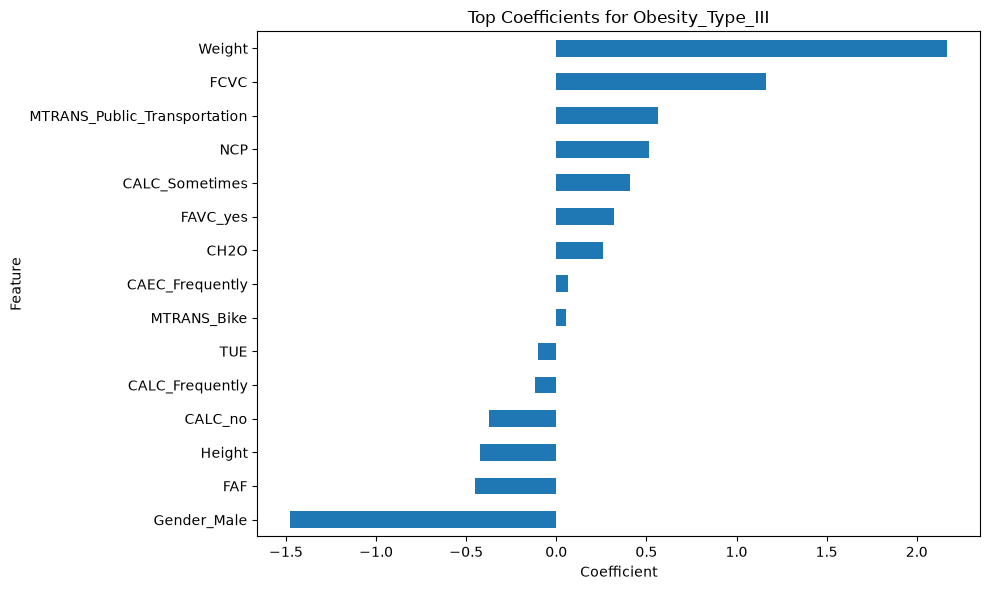

In [17]:
obesity_top_coefficients.sort_values("Coefficient").plot(
    x="Feature",
    y="Coefficient",
    kind="barh",
    legend=False,
    figsize=(10, 6)
)

plt.title(f"Top Coefficients for {obesity_class_label}")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

- The coefficient plot visually confirms that `Weight` had the s**trongest positive effect** for predicting `Obesity_Type_III`.

- The plot also shows that **several predictors had negative coefficients**, meaning they moved the model away from the `Obesity_Type_III` class. 

- This is useful for interpretation because regularized logistic regression still allows us to inspect which variables are most **influential** **after coefficient shrinkage**.

#### [Dataset 2] | *8- Classification report and confusion matrix for obesity*

In [18]:
best_obesity_pred = best_obesity_search.best_estimator_.predict(X_obesity_test)

print(classification_report(
    y_obesity_test,
    best_obesity_pred,
    digits=3
))

obesity_confusion = pd.DataFrame(
    confusion_matrix(
        y_obesity_test,
        best_obesity_pred,
        labels=best_obesity_search.best_estimator_.named_steps["logit"].classes_
    ),
    index=[f"Actual {label}" for label in best_obesity_search.best_estimator_.named_steps["logit"].classes_],
    columns=[f"Predicted {label}" for label in best_obesity_search.best_estimator_.named_steps["logit"].classes_]
)

display(obesity_confusion)

                     precision    recall  f1-score   support

Insufficient_Weight      0.788     0.963     0.867        54
      Normal_Weight      0.732     0.517     0.606        58
     Obesity_Type_I      0.699     0.729     0.713        70
    Obesity_Type_II      0.795     0.967     0.872        60
   Obesity_Type_III      0.955     0.985     0.970        65
 Overweight_Level_I      0.702     0.690     0.696        58
Overweight_Level_II      0.609     0.483     0.538        58

           accuracy                          0.764       423
          macro avg      0.754     0.762     0.752       423
       weighted avg      0.756     0.764     0.754       423



,Predicted Insufficient_Weight,Predicted Normal_Weight,Predicted Obesity_Type_I,Predicted Obesity_Type_II,Predicted Obesity_Type_III,Predicted Overweight_Level_I,Predicted Overweight_Level_II
Actual Insufficient_Weight,52,2,0,0,0,0,0
Actual Normal_Weight,13,30,1,0,0,9,5
Actual Obesity_Type_I,0,0,51,11,2,2,4
Actual Obesity_Type_II,0,0,1,58,0,1,0
Actual Obesity_Type_III,0,0,0,1,64,0,0
Actual Overweight_Level_I,0,7,2,0,0,40,9
Actual Overweight_Level_II,1,2,18,3,1,5,28


- The **best obesity model** achieved the following class-level results:

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| Insufficient_Weight | 0.788 | 0.963 | 0.867 | 54 |
| Normal_Weight | 0.732 | 0.517 | 0.606 | 58 |
| Obesity_Type_I | 0.699 | 0.729 | 0.713 | 70 |
| Obesity_Type_II | 0.795 | 0.967 | 0.872 | 60 |
| Obesity_Type_III | 0.955 | 0.985 | 0.970 | 65 |
| Overweight_Level_I | 0.702 | 0.690 | 0.696 | 58 |
| Overweight_Level_II | 0.609 | 0.483 | 0.538 | 58 |

- **Overall performance**:

| Metric | Value |
|---|---:|
| Accuracy | 0.764 |
| Macro F1 | 0.752 |
| Weighted F1 | 0.754 |

- The model performed very well on `Obesity_Type_III`, with recall of 0.985 and F1-score of 0.970. It also performed well on `Insufficient_Weight` and `Obesity_Type_II`.

- The weakest class was `Overweight_Level_II`, with recall of 0.483 and F1-score of 0.538. 

- Most errors happened between nearby categories, especially between overweight and obesity type I categories. 

- This is expected because adjacent weight classes are more difficult to separate than extreme classes.

## Dataset 3: Cervical Cancer

#### [Dataset 3] | *1- Load preprocessed cervical cancer dataset*

In [2]:
cervical_path = "cervical_cancer_preprocessed_wk1.csv"


df_cervical_model = pd.read_csv(cervical_path)

print("Cervical cancer dataset shape:", df_cervical_model.shape)
display(df_cervical_model.head())

Cervical cancer dataset shape: (858, 62)


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Number of sexual partners_missing,First sexual intercourse_missing,Num of pregnancies_missing,Smokes_missing,Smokes (years)_missing,Smokes (packs/year)_missing,Hormonal Contraceptives_missing,Hormonal Contraceptives (years)_missing,IUD_missing,IUD (years)_missing,STDs_missing,STDs (number)_missing,STDs:condylomatosis_missing,STDs:cervical condylomatosis_missing,STDs:vaginal condylomatosis_missing,STDs:vulvo-perineal condylomatosis_missing,STDs:syphilis_missing,STDs:pelvic inflammatory disease_missing,STDs:genital herpes_missing,STDs:molluscum contagiosum_missing,STDs:AIDS_missing,STDs:HIV_missing,STDs:Hepatitis B_missing,STDs:HPV_missing,STDs: Time since first diagnosis_missing,STDs: Time since last diagnosis_missing,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,4.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,4.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0
2,34,1.0,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,4.0,3.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,4.0,3.0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,4.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0


#### [Dataset 3] | *2- Split cervical cancer predictors and target*

In [3]:
cervical_target = "Biopsy"

X_cervical = df_cervical_model.drop(columns=[cervical_target])
y_cervical = df_cervical_model[cervical_target].astype(int)

X_cervical_train, X_cervical_test, y_cervical_train, y_cervical_test = train_test_split(
    X_cervical,
    y_cervical,
    test_size=0.20,
    random_state=42,
    stratify=y_cervical
)

print("Training shape:", X_cervical_train.shape)
print("Testing shape:", X_cervical_test.shape)

display(y_cervical.value_counts().sort_index().to_frame("Class Count"))

Training shape: (686, 61)
Testing shape: (172, 61)


,Class Count
Biopsy,
0,803
1,55


- The cervical cancer dataset was split into training and testing sets using stratification.

- The executed split was:

| Split | Shape |
|---|---:|
| Training | (686, 61) |
| Testing | (172, 61) |

- The target class distribution was:

| Biopsy Class | Count |
|---:|---:|
| 0 | 803 |
| 1 | 55 |

- This is a h**ighly imbalanced binary classification problem**. 

    - Only 55 of the 858 observations are biopsy-positive. 
    - Therefore, accuracy alone is not enough, and the models are evaluated using balanced accuracy, recall, F1, ROC AUC, and average precision.

#### [Dataset 3] | *3- Tune regularized models for cervical cancer*

In [5]:
cervical_searches = tune_regularized_models(
    X_train=X_cervical_train,
    y_train=y_cervical_train,
    scoring_metric="average_precision"
)

cervical_tuning_summary = summarize_active_features(
    cervical_searches,
    X_cervical.columns
)

display(cervical_tuning_summary)

d:\BU\Summer 2026\DX799 O1 Data Science Capstone\HWs\MOD-C-1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\BU\Summer 2026\DX799 O1 Data Science Capstone\HWs\MOD-C-1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
d:\BU\Summer 2026\DX799 O1 Data Science Capstone\HWs\MOD-C-1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, l

,Model,Best C,Best l1_ratio,Active Features,Zeroed Features,Total Features,Best CV Score
0,Lasso-style logistic regression,10.0,NaN,58,3,61,0.706312
1,Ridge-style logistic regression,0.1,NaN,58,3,61,0.709256
2,Elastic-net logistic regression,0.1,0.25,56,5,61,0.707908


- The three **regularized logistic regression models** were tuned using: 
    - 3-fold cross-validation 
    - average precision.

- The executed tuning summary was:

| Model | Best C | Best l1_ratio | Active Features | Zeroed Features | Total Features | Best CV Score |
|---|---:|---:|---:|---:|---:|---:|
| **Lasso-style** logistic regression | 10.0 | NaN | 58 | 3 | 61 | 0.706312 |
| **Ridge-style** logistic regression | 0.1 | NaN | 58 | 3 | 61 | 0.709256 |
| **Elastic-net** logistic regression | 0.1 | 0.25 | 56 | 5 | 61 | 0.707908 |

- The best cross-validation score was slightly higher for the **Ridge-style** model, but the **Elastic-net** model removed the most predictors, leaving **56** active features and zeroing **5** features.

- Regularization controls coefficient size and can **reduce model complexity**. 

- **Elastic Net** provided the most feature reduction in this execution.

#### [Dataset 3] | *4- Evaluate cervical cancer models*

In [6]:
cervical_metrics = evaluate_binary_models(
    cervical_searches,
    X_cervical_test,
    y_cervical_test
)

display(cervical_metrics)

,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC AUC,Average Precision
Model,,,,,,,
Lasso-style logistic regression,0.953488,0.890457,0.600000,0.818182,0.692308,0.954263,0.670126
Ridge-style logistic regression,0.959302,0.893563,0.642857,0.818182,0.720000,0.957086,0.675829
Elastic-net logistic regression,0.959302,0.893563,0.642857,0.818182,0.720000,0.936759,0.679733


- The models were evaluated on the **held-out test set**.

- The results were:

| Model | Accuracy | Balanced Accuracy | Precision | Recall | F1 | ROC AUC | Average Precision |
|---|---:|---:|---:|---:|---:|---:|---:|
| **Lasso-style** logistic regression | 0.953488 | 0.890457 | 0.600000 | 0.818182 | 0.692308 | 0.954263 | 0.670126 |
| **Ridge-style** logistic regression | 0.959302 | 0.893563 | 0.642857 | 0.818182 | 0.720000 | 0.957086 | 0.675829 |
| **Elastic-net** logistic regression | 0.959302 | 0.893563 | 0.642857 | 0.818182 | 0.720000 | 0.936759 | 0.679733 |

- The **Elastic-net** model had the **highest average precision at 0.679733**, while **Ridge** had the **highest ROC AUC at 0.957086**. 

- **Ridge and Elastic Net** produced the **same accuracy, balanced accuracy, precision, recall, and F1.**

- Because the **positive biopsy class is rare**, average precision is especially **important**. Based on that metric, **Elastic Net** is selected as the **best model** here.

#### [Dataset 3] | *5- Visualize cervical cancer model performance and feature activity*

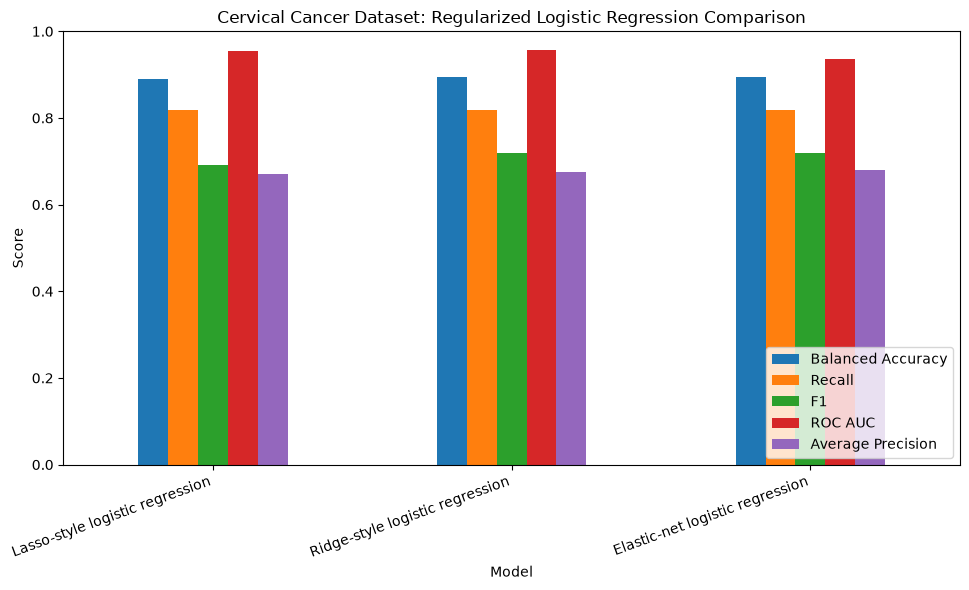

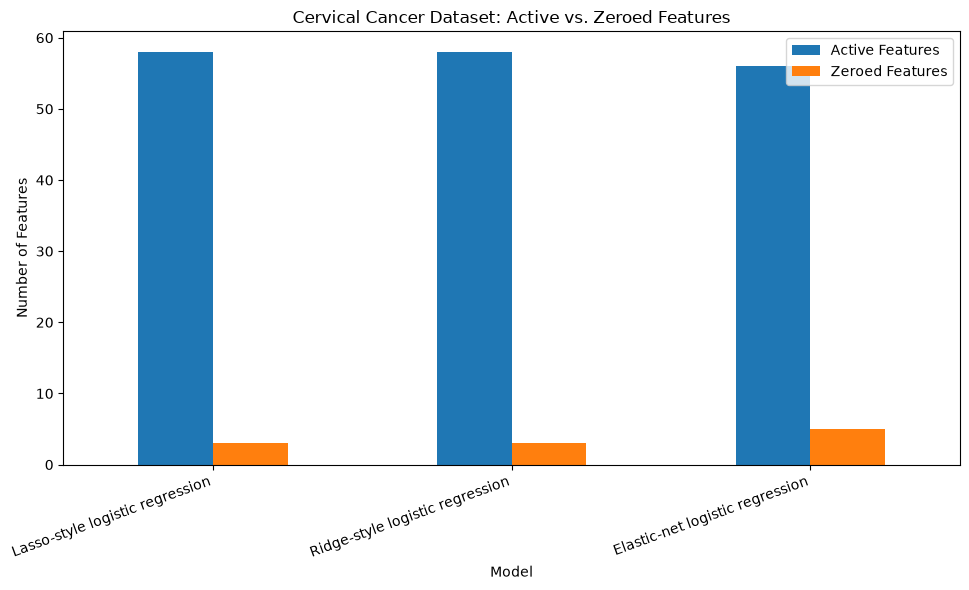

In [7]:
plot_metric_comparison(
    cervical_metrics[["Balanced Accuracy", "Recall", "F1", "ROC AUC", "Average Precision"]],
    "Cervical Cancer Dataset: Regularized Logistic Regression Comparison"
)

plot_active_features(
    cervical_tuning_summary,
    "Cervical Cancer Dataset: Active vs. Zeroed Features"
)

- The first plot compares the three regularized models using metrics that are appropriate for **imbalanced classification**.

- The second plot shows that **Elastic Net removed the most features**, with 5 zeroed predictors. Lasso-style and Ridge-style models each had 3 zeroed predictors in this execution.

- This result shows that the difference between Lasso, Ridge, and Elastic Net depends on the **data and the selected regularization strength**. 

- **Elastic Net** gave the **strongest feature reduction** while also producing the **best average precision**.

#### [Dataset 3] | *6- Select best cervical cancer model and inspect coefficients*

In [8]:
best_cervical_name = cervical_metrics["Average Precision"].idxmax()
best_cervical_search = cervical_searches[best_cervical_name]

print("Best cervical cancer model based on test Average Precision:", best_cervical_name)
print("Best parameters:", best_cervical_search.best_params_)

cervical_class_label, cervical_top_coefficients = get_top_coefficients(
    search=best_cervical_search,
    feature_names=X_cervical.columns,
    class_label=None,
    top_n=15
)

print("Coefficient class:", cervical_class_label)
display(cervical_top_coefficients)

Best cervical cancer model based on test Average Precision: Elastic-net logistic regression
Best parameters: {'logit__C': 0.1, 'logit__l1_ratio': 0.25}
Coefficient class: 1


,Feature,Coefficient,Absolute Coefficient
33,Schiller,0.895182,0.895182
32,Hinselmann,0.378696,0.378696
29,Dx:CIN,0.244247,0.244247
34,Citology,0.214718,0.214718
41,Hormonal Contraceptives_missing,-0.152872,0.152872
42,Hormonal Contraceptives (years)_missing,-0.152872,0.152872
37,Num of pregnancies_missing,0.121459,0.121459
3,Num of pregnancies,0.104007,0.104007
31,Dx,0.102413,0.102413
2,First sexual intercourse,-0.092155,0.092155


- The best cervical cancer model based on **test average precision** was:

| Best Model | Best Parameters |
|---|---|
| Elastic-net logistic regression | `C = 0.1`, `l1_ratio = 0.25` |

- The strongest coefficients for predicting `Biopsy = 1` were:

| Feature | Coefficient | Absolute Coefficient |
|---|---:|---:|
| Schiller | 0.895182 | 0.895182 |
| Hinselmann | 0.378696 | 0.378696 |
| Dx:CIN | 0.244247 | 0.244247 |
| Citology | 0.214718 | 0.214718 |
| Hormonal Contraceptives_missing | -0.152872 | 0.152872 |
| Hormonal Contraceptives (years)_missing | -0.152872 | 0.152872 |
| Num of pregnancies_missing | 0.121459 | 0.121459 |
| Num of pregnancies | 0.104007 | 0.104007 |
| Dx | 0.102413 | 0.102413 |
| First sexual intercourse | -0.092155 | 0.092155 |
| STDs:syphilis | -0.084673 | 0.084673 |
| STDs:HIV | 0.072747 | 0.072747 |
| Dx:HPV | 0.046213 | 0.046213 |
| STDs: Time since first diagnosis | -0.038617 | 0.038617 |
| IUD | 0.037883 | 0.037883 |

- The largest coefficient was `Schiller`, followed by `Hinselmann`, `Dx:CIN`, and `Citology`. 

    - This makes sense because `Hinselmann`, `Schiller`, and `Citology` are diagnostic-related variables


#### [Dataset 3] | *7- Visualize top cervical cancer coefficients*

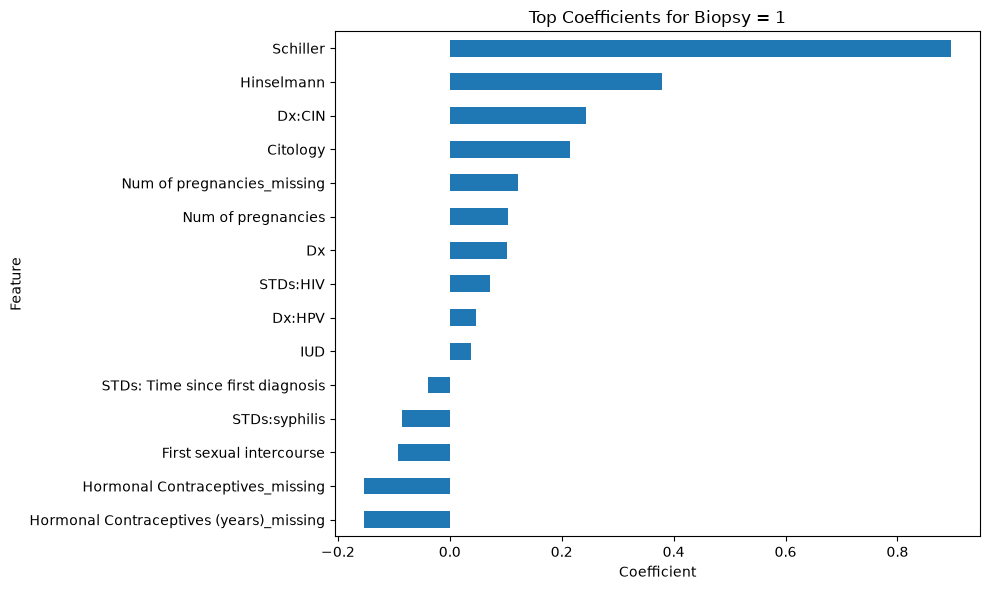

In [9]:
cervical_top_coefficients.sort_values("Coefficient").plot(
    x="Feature",
    y="Coefficient",
    kind="barh",
    legend=False,
    figsize=(10, 6)
)

plt.title("Top Coefficients for Biopsy = 1")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

- The coefficient plot shows that `Schiller` has the **strongest positive** relationship with predicting `Biopsy = 1`.

- `Hinselmann`, `Dx:CIN`, and `Citology` also push the model toward a positive biopsy prediction. 

- The **negative coefficients**, such as the **missingness indicators** for hormonal contraceptive variables, push the model away from predicting `Biopsy = 1`.

- the **Elastic-net** interpretation: the model **keeps** the strongest predictors while applying **shrinkage** to control coefficient size.

#### [Dataset 3] | *8- Classification report and confusion matrix for cervical cancer*

In [10]:
best_cervical_pred = best_cervical_search.best_estimator_.predict(X_cervical_test)

print(classification_report(
    y_cervical_test,
    best_cervical_pred,
    digits=3,
    zero_division=0
))

cervical_confusion = pd.DataFrame(
    confusion_matrix(y_cervical_test, best_cervical_pred),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(cervical_confusion)

              precision    recall  f1-score   support

           0      0.987     0.969     0.978       161
           1      0.643     0.818     0.720        11

    accuracy                          0.959       172
   macro avg      0.815     0.894     0.849       172
weighted avg      0.965     0.959     0.962       172



,Predicted 0,Predicted 1
Actual 0,156,5
Actual 1,2,9


- This is a strong result for an imbalanced medical classification problem. 

- However, the performance is partly helped by including diagnostic variables such as `Schiller`, `Hinselmann`, and `Citology`.

#### [Dataset 3] | *9- Summary*


- For the cervical cancer dataset, Elastic Net performed best by average precision and removed the most features. 

- This makes it a good balance between prediction and model simplification.
